# E1 Baseline Model — TF-IDF + Logistic Regression
**Project:** Social Media Sentiment & Hate Detection  
**Experiment:** E1 — Classical NLP Baseline  
**Dataset:** [TweetEval](https://huggingface.co/datasets/cardiffnlp/tweet_eval) (`sentiment` and `hate` subsets)

---

## Overview

This notebook implements **Experiment 1 (E1)**: a classical NLP baseline using a TF-IDF vectoriser paired with Logistic Regression, applied independently to two tasks:

| Task | Labels | Train size |
|---|---|---|
| Sentiment Analysis | 3-class (negative / neutral / positive) | 45,615 |
| Hate Speech Detection | 2-class (non-hate / hate) | 9,000 |

**Design decisions:**
- **No stopword removal** — negation words (`not`, `never`, `no`) carry direct sentiment signal and must be preserved.
- **No hyperparameter tuning** — the baseline intentionally uses default `C=1` to remain unoptimised, giving a fair lower bound for comparison against E2.
- **Self-contained** — the notebook re-loads data directly from HuggingFace; it does not depend on any outputs from `data_analysis.ipynb`.

**Notebook structure:**
1. Imports & Constants  
2. Text Preprocessing (`clean_text`)  
3. Data Loading & Preprocessing  
4. Pipeline Definition  
5. Model Training  
6. Evaluation  
7. Confusion Matrices  
8. Results Summary & Conclusion


## 1. Imports & Constants

All required libraries are imported here. Constants are centralised so they can be changed in one place without touching the rest of the notebook.

| Constant | Value | Purpose |
|---|---|---|
| `SEED` | 42 | Reproducibility for Logistic Regression |
| `MAX_FEATURES` | 50,000 | TF-IDF vocabulary cap (unigrams + bigrams) |
| `NGRAM_RANGE` | (1, 2) | Include both unigrams and bigrams |


In [3]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [4]:
SEED = 42
MAX_FEATURES = 50000
NGRAM_RANGE=(1, 2)

## 2. Text Preprocessing — `clean_text`

This is the **canonical definition** of `clean_text`. The same function is explored in `data_analysis.ipynb` during EDA, but its authoritative home is here.

**Preprocessing pipeline (order matters):**

1. **Lowercase** — standardise casing.
2. **Mention anonymisation** — replace raw `@username` tokens with `@user`. The dataset already anonymises some mentions, but not all (359 raw mentions found in the sentiment train split, 85 in hate train). The regex `@(?!user)\w+` uses a negative lookahead to skip already-anonymised tokens.
3. **URL removal** — remove `http`/`https` links (21 found in sentiment train, 125 in hate train).
4. **Hashtag normalisation** — strip `#` symbol while keeping the hashtag text (e.g., `#NLP` → `NLP`).
5. **Whitespace normalisation** — strip leading/trailing whitespace and collapse internal runs.

> **Note:** Slurs and offensive language are intentionally **not** removed. They carry direct signal for hate speech detection.


In [9]:
def clean_text(text):

    # 1. Lowercase
    lower_text = text.lower()

    # 2. User anonymization
    mention_pattern = r'@(?!user)\w+'
    anony_text = re.sub(mention_pattern, ' @user', lower_text)

    # 3. URL Removal
    no_url_text = re.sub(r'https?://\S+', '', anony_text)
    
    # 4. Stripping hashtag but keeping hastag content
    removed_hash_text = no_url_text.replace("#", "")
    
    # 5. Normalize whitespace(strip + collapse internal spaces)
    stripped_text = removed_hash_text.strip()
    cleaned_text = " ".join(stripped_text.split())

    return cleaned_text

## 3. Data Loading & Preprocessing

The TweetEval dataset is loaded directly from HuggingFace.  
`set_format(type="pandas")` converts HuggingFace `Arrow` tables into pandas DataFrames for easier manipulation.

**Empty-row handling (hate dataset only):**  
EDA revealed 2 empty rows in hate train and 1 in hate val. These are dropped via a whitespace-to-NaN replacement followed by `dropna`. The sentiment splits are clean and require no such handling.

After loading, `clean_text` is applied to all six splits, creating a new `clean_text` column while preserving the original `text` column for reference.


In [7]:
ds_senti = load_dataset("cardiffnlp/tweet_eval", "sentiment")
ds_hate = load_dataset("cardiffnlp/tweet_eval", "hate")

ds_senti.set_format(type="pandas")
senti_train = ds_senti["train"][:]
senti_test = ds_senti["test"][:]
senti_val = ds_senti["validation"][:]

ds_hate.set_format(type="pandas")
hate_train = ds_hate["train"][:]
hate_test = ds_hate["test"][:]
hate_val = ds_hate["validation"][:]

In [8]:
# Dropping Null values from hate train and val splits which was observed during EDA
hate_train = hate_train.replace(r'^\s*$', np.nan, regex=True).dropna(subset=['text']).reset_index(drop=True)
hate_val = hate_val.replace(r'^\s*$', np.nan, regex=True).dropna(subset=['text']).reset_index(drop=True)

In [10]:
senti_train["clean_text"] = senti_train["text"].apply(clean_text)
senti_val["clean_text"] = senti_val["text"].apply(clean_text)
senti_test["clean_text"] = senti_test["text"].apply(clean_text)

hate_train["clean_text"] = hate_train["text"].apply(clean_text)
hate_val["clean_text"] = hate_val["text"].apply(clean_text)
hate_test["clean_text"] = hate_test["text"].apply(clean_text)

## 4. Pipeline Definition

Two independent sklearn `Pipeline` objects are built — one per task.  
Each pipeline chains:

1. **`TfidfVectorizer`** — converts cleaned tweet text into a TF-IDF matrix.  
   - `max_features=50_000`: caps vocabulary to the top 50k terms by frequency.  
   - `ngram_range=(1, 2)`: includes both unigrams and bigrams; bigrams capture short phrase patterns (e.g., "not good", "hate speech").  
   - No stopword removal — intentional; see design decisions above.

2. **`LogisticRegression`**  
   - `solver='lbfgs'` for **sentiment** (multi-class, 3 classes — lbfgs handles multinomial natively).  
   - `solver='liblinear'` for **hate** (binary, 2 classes — liblinear is efficient for binary problems).  
   - `max_iter=1000` to ensure convergence.  
   - `random_state=SEED` for reproducibility.


In [11]:
senti_pipeline = Pipeline([
    ('senti_vectorizer', TfidfVectorizer(max_features=MAX_FEATURES, ngram_range=NGRAM_RANGE)),
    ('senti_classifier', LogisticRegression(random_state=SEED, max_iter=1000, solver='lbfgs'))
])

hate_pipeline = Pipeline([
    ('hate_vectorizer', TfidfVectorizer(max_features=MAX_FEATURES, ngram_range=NGRAM_RANGE)),
    ('hate_classifier', LogisticRegression(random_state=SEED, max_iter=1000, solver='liblinear'))
])

## 5. Model Training

Features (`X`) and labels (`y`) are extracted from the `clean_text` and `label` columns respectively.  
Both pipelines are fit on their respective training splits.


In [12]:
X_senti_train = senti_train["clean_text"]
y_senti_train = senti_train["label"]

X_hate_train = hate_train["clean_text"]
y_hate_train = hate_train["label"]

In [13]:
senti_pipeline.fit(X_senti_train, y_senti_train)
hate_pipeline.fit(X_hate_train, y_hate_train)

,steps,"[('hate_vectorizer', ...), ('hate_classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


## 6. Evaluation

### Evaluation strategy

- **Validation set** — used as a sanity check during development only.
- **Test set** — the **official reported numbers** (used in the final results table and report).

The `print_model_evaluation` function prints per-class precision, recall, F1-score and overall accuracy for both val and test splits in a structured format.

> **Primary metric:** Macro-F1 (unweighted average across classes). Accuracy alone is misleading on imbalanced distributions — in particular, the sentiment train split is moderately imbalanced (negative class ~16%).


In [18]:
X_senti_val = senti_val["clean_text"]
y_senti_val_true = senti_val["label"]

X_senti_test = senti_test["clean_text"]
y_senti_test_true = senti_test["label"]

X_hate_val = hate_val["clean_text"]
y_hate_val_true = hate_val["label"]

X_hate_test = hate_test["clean_text"]
y_hate_test_true = hate_test["label"]

In [19]:
y_senti_val_pred = senti_pipeline.predict(X_senti_val)
y_senti_test_pred = senti_pipeline.predict(X_senti_test)

y_hate_val_pred = hate_pipeline.predict(X_hate_val)
y_hate_test_pred = hate_pipeline.predict(X_hate_test)

In [26]:
def print_model_evaluation(task_name, y_val_true, y_val_pred, y_test_true, y_test_pred):
    # Calculate overall accuracies
    val_acc = accuracy_score(y_val_true, y_val_pred)
    test_acc = accuracy_score(y_test_true, y_test_pred)
    
    # Generate classification reports
    val_report = classification_report(y_val_true, y_val_pred)
    test_report = classification_report(y_test_true, y_test_pred)
    
    # Visual Separators
    double_line = "=" * 60
    single_line = "-" * 60
    
    print(f"\n{double_line}")
    print(f" EVALUATION REPORT: {task_name.upper()} ")
    print(f"{double_line}")
    
    # --- VALIDATION SET ---
    print(f"\n🔹VALIDATION SET PERFORMANCE")
    print(f"Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")
    print(single_line)
    print(val_report)
    print(single_line)
    
    # --- TEST SET ---
    print(f"\n🔸TEST SET PERFORMANCE")
    print(f"Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
    print(single_line)
    print(test_report)
    print(double_line)

# --- HOW TO RUN IT ---
# Pass your true labels and predictions directly into the function
print_model_evaluation("Sentiment Analysis", y_senti_val_true, y_senti_val_pred, y_senti_test_true, y_senti_test_pred)
print_model_evaluation("Hate Speech Detection", y_hate_val_true, y_hate_val_pred, y_hate_test_true, y_hate_test_pred)


 EVALUATION REPORT: SENTIMENT ANALYSIS 

🔹VALIDATION SET PERFORMANCE
Accuracy: 0.6840 (68.40%)
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.64      0.38      0.48       312
           1       0.64      0.77      0.70       869
           2       0.76      0.70      0.73       819

    accuracy                           0.68      2000
   macro avg       0.68      0.62      0.64      2000
weighted avg       0.69      0.68      0.68      2000

------------------------------------------------------------

🔸TEST SET PERFORMANCE
Accuracy: 0.5912 (59.12%)
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.69      0.32      0.44      3972
           1       0.59      0.76      0.66      5937
           2       0.53      0.61      0.57      2375

    accuracy                           0.59     12284
   macro avg       

## 7. Confusion Matrices (Test Set)

Confusion matrices for both tasks on the **test set**.  
The display uses a blue colour map; darker cells indicate higher counts.

**Label mappings:**
- Sentiment: `0 = negative`, `1 = neutral`, `2 = positive`
- Hate: `0 = non-hate`, `1 = hate`


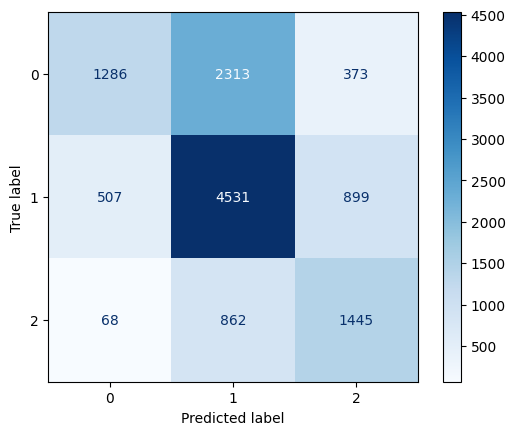

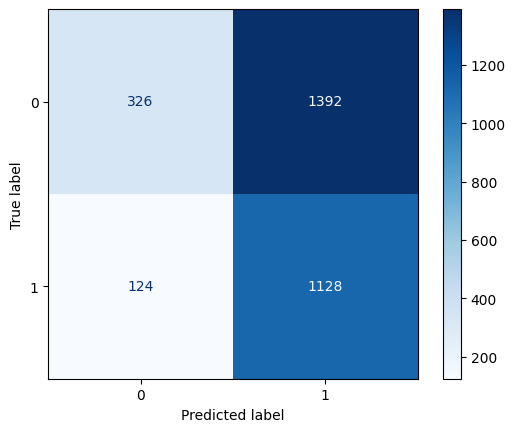

In [29]:
def plot_confusion_matrix(task_name, y_true, y_pred):
    # Generate the raw numerical matrix
    cm = confusion_matrix(y_true, y_pred)

    # Plot the visual matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix — {task_name} (Test Set)")
    
    # Show the plot
    plt.show()

plot_confusion_matrix("Sentiment Analysis", y_senti_test_true, y_senti_test_pred)
plot_confusion_matrix("Hate Speech Detection", y_hate_test_true, y_hate_test_pred)


## 8. Results Summary & Conclusion

### E1 Baseline Results (Test Set)

| Model | Task | Accuracy | Macro-F1 |
|---|---|---|---|
| TF-IDF + LR | Sentiment Analysis | 0.5916 | 0.56 |
| TF-IDF + LR | Hate Speech Detection | 0.4896 | 0.45 |

### Per-class breakdown

**Sentiment (Test):**

| Class | Precision | Recall | F1 |
|---|---|---|---|
| 0 — Negative | 0.69 | 0.32 | 0.44 |
| 1 — Neutral | 0.59 | 0.76 | 0.66 |
| 2 — Positive | 0.53 | 0.61 | 0.57 |

**Hate Speech (Test):**

| Class | Precision | Recall | F1 |
|---|---|---|---|
| 0 — Non-hate | 0.72 | 0.19 | 0.30 |
| 1 — Hate | 0.45 | 0.90 | 0.60 |

---

### Key Observations

**Sentiment:**
- Validation macro-F1 (0.63) is 7 points higher than test macro-F1 (0.56).  
  This gap is caused by a **distribution shift** in the test split — negative class rises from ~15.5% (train) to ~32.3% (test), while positive drops from ~39% to ~19.3%. This is a known TweetEval benchmark artefact and cannot be fixed; it is documented as a limitation.
- The model systematically under-recalls the **negative** class (F1 = 0.44), which is the least-represented class in training (~16%). This motivates the weighted-loss experiment in E3.

**Hate Speech:**
- A dramatic collapse from validation macro-F1 (0.71) to test macro-F1 (0.45).
- The confusion matrix reveals a **systematic bias toward predicting hate**: non-hate recall = 0.19 vs hate recall = 0.90. The model labels almost everything as hate.
- Two competing hypotheses explain this:
  - **H1 — Lexical ambiguity (counter-speech):** TF-IDF conflates hate-adjacent vocabulary used in counter-speech, condemnation, and reporting with actual hate speech. This is a structural bag-of-words limitation.
  - **H2 — Domain/source shift:** Train and test splits may come from different collection periods or sources, causing vocabulary drift.
- This is **not** a class-imbalance problem (hate split is only mildly imbalanced at ~42% hate / ~58% non-hate). The root cause is the feature-space limitation of TF-IDF, which directly motivates the transition to context-aware RoBERTa fine-tuning in **E2**.

---

### Conclusion

The TF-IDF + Logistic Regression baseline establishes a lower-bound benchmark for both tasks. For sentiment, the model performs reasonably well (0.56 macro-F1) given the simplicity of the approach, with its main weakness being the underrepresented negative class. For hate speech detection, the baseline fails structurally — not because of poor training, but because bag-of-words representations cannot distinguish semantic context (genuine hate vs. counter-speech). Both findings directly motivate the architectural choices in the transformer experiments (E2, E3):

- **E2** (RoBERTa fine-tuning) addresses the context blindness of TF-IDF.
- **E3** (weighted loss) targets the negative-class recall weakness in sentiment.
